# Notebook 7: Autoencoders

In the previous notebook, we used GANs to generate synthetic images of handwritten digits by sampling low-dimensional __latent__ noise vectors. What if we wanted to go in the opposite direction? That is, what if we wanted to map images to a highly informative, compressed representation from which we could __reconstruct__ them with minimal error? This is the motivation behind __autoencoders__, models that learn to encode (compress) and then decode (reconstruct) their inputs. In this notebook, we'll look at a simple autoencoder model and explore some of the many uses of this architecture.

The notebook is broken up as follows:

  1. [Setup](#setup)  
  2. [What Are Autoencoders?](#intro)  
  3. [A Simple MNIST Autoencoder](#mnist)
  4. [An Autoencoder for Inpainting](#inpainting)

## __1.__ <a name="setup">Setup</a>


In [ ]:
# helper code from the course repository
!git clone https://github.com/interactiveaudiolab/course-deep-learning.git
# install common pacakges used for deep learning
!cd course-deep-learning/ && pip install -r requirements.txt

In [ ]:
%matplotlib inline
%cd course-deep-learning/

import datetime
import math
import torch
import matplotlib.pyplot as plt
import numpy as np
import IPython.display as ipd
from matplotlib.animation import FuncAnimation
from pathlib import Path
from torch.utils.tensorboard import SummaryWriter
from torchsummary import summary
from tqdm import tqdm

from utils.gan import *

## __2.__ <a name="intro">What Are Auroencoders?</a>

Autoencoders are neural networks trained to encode (compress) and then decode (reconstruct) their inputs. They are composed of two sub-networks: an __encoder__ $E$, which maps data $x$ to a (typically low-dimensional) latent representation $E(x)$; and a __decoder__ $D$, which maps latent representations back to the input space in order to reconstruct the data $D(E(x))$. Autoencoders are often used in applications where a low-dimensional representation of high-dimensional data is required, and in many cases only the encoder component may be of interest.

<br/>
<center>
<img width="600px" src="https://drive.google.com/uc?export=view&id=1t8I7tuOcWZWxaSS8gmDb3z5PyEBuUgNy"/>
</center>
<br/>

So why is the decoder necessary? Note that it's not enough for the encoder network to map inputs to some arbitrary low-dimensional representation; after all, we could trivially map all inputs to a one-dimensional unit vector. Rather, we want the encoder to learn a mapping that preserves as much information as possible about the inputs, so that we get the benefits of reduced dimensionality without losing sight of important features of the data. One way to accomplish this is to use a decoder to map compressed representations back to inputs. Training the encoder and decoder simultaneously then incentivizes the encoder to learn mappings that preserve enough information for the decoder to successfully reconstruct inputs. For many types of data, this training procedure can be captured with a straightforward objective. Assume we have a dataset of $n$ inputs, each of which is $d$-dimensional; then we can simply compute the mean-squared error over all input-output pairs for our autoencoder:

$$\min_{\theta_E, \theta_D} \frac{1}{m \cdot n} \sum_{i = 1}^{n} \sum_{j = 1}^{d} \left(x_i^{(j)} - D(E(x_i^{(j)}))\right)^2$$

where $x_i^{(j)}$ is the $j^{\mathrm{th}}$ coordinate of the $i^{\mathrm{th}}$ input, $\theta_E$ is the set of encoder parameters, and $\theta_D$ is the set of decoder parameters. That is, we penalize how different the autoencoder's outputs are from its inputs. In the following sections, we'll design a simple autoencoder architecture and explore how this model can be adapted for different uses with only small changes to our training procedure.

This tutorial is necessarily brief, but if you want to dive in deeper feel free to check out these resources:
* [Autoencoder In PyTorch](https://www.youtube.com/watch?v=zp8clK9yCro)
* [Building a Pytorch Autoencoder for MNIST Digits](https://bytepawn.com/building-a-pytorch-autoencoder-for-mnist-digits.html)
* [Autoencoders](https://www.deeplearningbook.org/contents/autoencoders.html)

## __3.__ <a name="mnist">A Simple MNIST Autoencoder</a>

As in the previous notebook, we'll start by wrapping two simple MLP-based networks into a single model. The encoder will map flattened MNIST images to low-dimensional latent vectors, while the decoder will map latent vectors to images. While our autoencoder is similar to our GAN in this regard, it's important to note the key differences between these architectures.

* GANs learn to map points drawn from a latent noise distribution to realistic instances by playing a "competitive game" between the generator and discriminator
* Autoencoders learn to map inputs to a latent representation, from which they can be reconstructed with high fidelity using a corresponding decoder. The encoder and decoder networks are trained "cooperatively" in this regard.
* GANs are typically used to sample new instances from the data distribution, while traditional autoencoders do not allow for sampling from the data distribution.

That said, there exist special types of autoencoders -- such as [variational autoencoders (VAEs)](https://ermongroup.github.io/cs228-notes/extras/vae/) -- that _do_ allow for generating new instances from the data distribution. We won't be covering those here, but we will look at an interesting application of autoencoders beyond simply learning low-dimensional data representations.

In [ ]:
class MLPEncoder(torch.nn.Module):

    def __init__(self,
                 number_of_hidden_layers: int,
                 input_size: int,
                 hidden_size: int,
                 latent_size: int,
                 activation: torch.nn.Module):
        """Construct a simple MLP encoder"""

        super().__init__()

        assert number_of_hidden_layers >= 0, "Encoder number_of_hidden_layers must be at least 0"

        dims_in = [input_size] + [hidden_size] * number_of_hidden_layers
        dims_out = [hidden_size] * number_of_hidden_layers + [latent_size]  # final output should be latent size
        layers = []
        for i in range(number_of_hidden_layers + 1):
            layers.append(torch.nn.Linear(dims_in[i], dims_out[i]))

            if i < number_of_hidden_layers:
                layers.append(activation)

        self.net = torch.nn.Sequential(*layers)

    def forward(self, x: torch.Tensor):
        return self.net(x)


class MLPDecoder(torch.nn.Module):

    def __init__(self,
                 number_of_hidden_layers: int,
                 latent_size: int,
                 hidden_size: int,
                 input_size: int,
                 activation: torch.nn.Module):
        """Construct a simple MLP decoder"""

        super().__init__()

        assert number_of_hidden_layers >= 0, "Decoder number_of_hidden_layers must be at least 0"

        dims_in = [latent_size] + [hidden_size] * number_of_hidden_layers
        dims_out = [hidden_size] * number_of_hidden_layers + [input_size]  # final output is an image

        layers = []
        for i in range(number_of_hidden_layers + 1):
            layers.append(torch.nn.Linear(dims_in[i], dims_out[i]))

            if i < number_of_hidden_layers:
                layers.append(activation)

        # apply Tanh after final layer to bound pixels to range [-1, 1]
        layers.append(torch.nn.Sigmoid())

        self.net = torch.nn.Sequential(*layers)

    def forward(self, x: torch.Tensor):
        return self.net(x)


class MLPAutoencoder(torch.nn.Module):

    def __init__(self,
                 number_of_hidden_layers: int,
                 input_size: int,
                 hidden_size: int,
                 latent_size: int,
                 activation_encoder: torch.nn.Module = torch.nn.ReLU(),
                 activation_decoder: torch.nn.Module = torch.nn.LeakyReLU(0.2)
                ):
        """Construct a simple MLP autoencoder

        number_of_hidden_layers: An int. Must be >=0. Defines the number of
                hidden layers for both the encoder E and decoder D
        latent_size:  An int. Defines the size of the latent representation produced by
                      the encoder.
        hidden_size: An int. The size of each hidden layer for the encoder E and
                     the decoder D.
        input_size: An int. Determines the size of the input and output images
        activation_encoder: A torch.nn.Module defining the activation function in every
                            hidden layer of the encoder.
        activation_decoder: A torch.nn.Module defining the activation function in every
                            hidden layer of the decoder.
        """
        super().__init__()

        self.encoder = MLPEncoder(
            number_of_hidden_layers=number_of_hidden_layers,
            input_size=input_size,
            hidden_size=hidden_size,
            latent_size=latent_size,
            activation=activation_encoder
        )

        self.decoder = MLPDecoder(
            number_of_hidden_layers=number_of_hidden_layers,
            input_size=input_size,
            hidden_size=hidden_size,
            latent_size=latent_size,
            activation=activation_decoder
        )

    def encode(self, x: torch.Tensor):
        return self.encoder(x)

    def decode(self, x: torch.Tensor):
        return self.decoder(x)

    def forward(self, x: torch.Tensor):
        return(self.decode(self.encode(x)))


#### Training Configuration

To view progress after starting your training loop below, you may need to refresh Tensorboard (an icon should appear in the top-right corner of the following cell).

In [ ]:
# here, we'll initialize TensorBoard. You should see an empty window in this cell, which will populate with
# graphs as soon as we run our training code below.
%load_ext tensorboard
%tensorboard --logdir logs --port 6006

In [ ]:
# autoencoder training hyperparameters
image_size = 28
batch_size = 64
latent_size = 64
hidden_size = 256
number_of_hidden_layers = 2
lr = 0.0002
epochs = 30

# fix random seed
torch.manual_seed(0)

# select device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# load MNIST dataset
mnist = load_mnist(batch_size=batch_size)

# initialize the model
model = MLPAutoencoder(
    number_of_hidden_layers=number_of_hidden_layers,
    latent_size=latent_size,
    hidden_size=hidden_size,
    input_size=image_size*image_size,
).to(device)

# use an optimizer to handle parameter updates
opt = torch.optim.Adam(model.parameters(), lr=lr)

# loss function: mean-squared error between original and reconstructed images
loss = torch.nn.MSELoss()

# save all log data to a local directory
run_dir = "logs"

# to clear out TensorBoard and start totally fresh, we'll need to
# remove old logs by deleting them from the directory
!rm -rf ./logs/

# timestamp the logs for each run so we can sort through them
run_time = datetime.datetime.now().strftime("%I:%M%p on %B %d, %Y")

# initialize a SummaryWriter object to handle all logging actions
logger = SummaryWriter(log_dir=Path(run_dir) / run_time, flush_secs=20)

# log reconstructions of a fixed set of images during training
example_batch, _ = next(iter(mnist))
example_batch = example_batch.to(device)
logger.add_image("training_images", make_grid(example_batch, math.floor(math.sqrt(batch_size))), 0)

#### Training Loop

We're ready to train! Check out the TensorBoard cell above to view training results in real time (you may need to periodically refresh using the icon in the upper right corner). If you're using Google Colab with a GPU enabled, training through all 30 epochs should take around five minutes.

In [ ]:
for epoch in range(epochs):

    # weight batch losses/scores proportional to batch size
    iter_count = 0
    loss_epoch = 0

    for batch_idx, batch_data in enumerate(mnist):

        # we only care about inputs, not labels
        x_real, _ = batch_data

        # flatten input images and move to device
        x_real = x_real.to(device)
        n_batch = x_real.shape[0]
        x_real = x_real.reshape(n_batch, -1)

        model.zero_grad()

        # train on a batch of inputs
        x_reconstructed = model(x_real)
        loss_batch = loss(x_real, x_reconstructed)
        loss_batch.backward()
        opt.step()

        # log loss
        loss_epoch += loss_batch.detach().item() * n_batch
        iter_count += n_batch

    # plot loss
    loss_epoch /= iter_count
    logger.add_scalar("mse_loss", loss_epoch, epoch)

    # plot example generated images
    with torch.no_grad():
        reconstructed_batch = model(example_batch.reshape(batch_size, -1)).reshape(batch_size, 1, image_size, image_size)
        logger.add_image("reconstructed_images", make_grid(reconstructed_batch, math.floor(math.sqrt(batch_size)), title="Reconstructed Images"), epoch)

    if not epoch % 10:
        print(f"Epoch: {epoch + 1}\tMSE Loss: {loss_epoch :0.4f}")

We can see that our autoencoder learns to reconstruct its training data relatively faithfully. More impressively, it does so using a 64-dimensional latent representation -- meaning that we've compressed the size of our image data by a factor of 12. This means we could use our model as a "codec" to compress and efficiently store images by encoding; the full-resolution images could then be recovered as needed by decoding.

Another potential use of our autoencoder is __denoising__. As it turns out, because our model has learned to map "clean" images to low-dimensional vectors containing only the most salient information, it will discard small amounts of noise when reconstructing images!

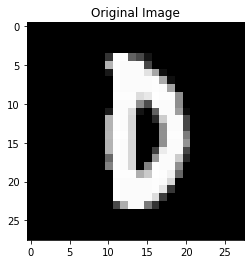

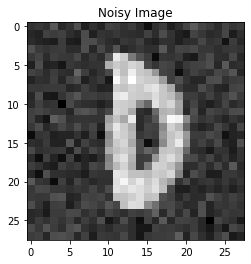

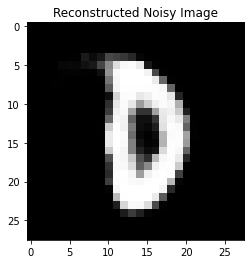

In [ ]:
example_image = example_batch[0].cpu()
plt.imshow(example_image.squeeze(), cmap='gray')
plt.title("Original Image")
plt.show()

noisy_image = example_image + torch.randn_like(example_image) * 0.1
plt.imshow(noisy_image.squeeze(), cmap='gray')
plt.title("Noisy Image")
plt.show()

reconstructed_image = model(noisy_image.flatten().unsqueeze(0).to(device)).reshape(1, image_size, image_size).detach().cpu()
plt.imshow(reconstructed_image.squeeze(), cmap='gray')
plt.title("Reconstructed Noisy Image")
plt.show()

## __4.__ <a name="inpainting">An Autoencoder for Inpainting</a>

Above, we saw how our autoencoder could remove noise from images, even without explicitly training it to do so. To allow our autoencoder to "restore" images with more extreme degradations, we can modify our training process such that the model receives degraded images but is evaluated on how well its outputs match the corresponding "clean" images. In particular, we will apply a __mask__ to a random location in each input image to remove information. The autoencoder will then have to fill in the missing portion of the image. This is called __inpainting__.

#### Training Configuration

We'll use the same model configuration as above, and change only our training loop. To view progress after starting your training loop below, you may need to refresh Tensorboard (an icon should appear in the top-right corner of the following cell).

In [ ]:
# here, we'll initialize TensorBoard. You should see an empty window in this cell, which will populate with
# graphs as soon as we run our training code below.
%load_ext tensorboard
%tensorboard --logdir logs --port 6006

In [ ]:
# fix random seed
torch.manual_seed(0)

# initialize the model
model = MLPAutoencoder(
    number_of_hidden_layers=number_of_hidden_layers,
    latent_size=latent_size,
    hidden_size=hidden_size,
    input_size=image_size*image_size,
).to(device)

# use an optimizer to handle parameter updates
opt = torch.optim.Adam(model.parameters(), lr=lr)

# timestamp the logs for each run so we can sort through them
run_time = datetime.datetime.now().strftime("%I:%M%p on %B %d, %Y")

# initialize a SummaryWriter object to handle all logging actions
logger = SummaryWriter(log_dir=Path(run_dir) / run_time, flush_secs=20)

# log reconstructions of a fixed set of images during training
example_batch, _ = next(iter(mnist))
example_batch = example_batch.to(device)
logger.add_image("training_images", make_grid(example_batch, math.floor(math.sqrt(batch_size))), 0)

#### Training Loop

For each batch, we'll randomly apply a square mask to each image to remove information. However, we will use the original "unmasked" version of each image as a target. This will force our autoencoder to learn to reconstruct the missing information.

In [ ]:
def apply_mask(x: torch.Tensor, image_size: int, mask_size: int):
    """Apply random masks to each input in batch"""

    n_batch = x.shape[0]

    # mask placement can be defined by location of upper-left corner
    valid_idx = image_size - mask_size - 1
    batch_corners = torch.randint(low=0, high=valid_idx, size=(n_batch, 2))

    x_masked = x.clone()

    # apply masks to each image in batch
    for i in range(n_batch):
        x_masked[
                  i, :,
                  batch_corners[i][0]: batch_corners[i][0]+mask_size,
                  batch_corners[i][1]: batch_corners[i][1]+mask_size,
                  ] = 0
    return x_masked

In [ ]:
# we'll start with small 10x10 masks
mask_size = 10

for epoch in range(epochs):

    # weight batch losses/scores proportional to batch size
    iter_count = 0
    loss_epoch = 0

    for batch_idx, batch_data in enumerate(mnist):

        # we only care about inputs, not labels
        x_real, _ = batch_data

        # obtain batch of inputs and move to device
        x_real = x_real.to(device)
        n_batch = x_real.shape[0]

        # apply random masks
        x_masked = apply_mask(x_real, image_size, mask_size)
        x_masked = x_masked.reshape(n_batch, -1)

        # flatten input images
        x_real = x_real.reshape(n_batch, -1)

        model.zero_grad()

        # train on a batch of inputs
        x_reconstructed = model(x_masked)
        loss_batch = loss(x_real, x_reconstructed)
        loss_batch.backward()
        opt.step()

        # log loss
        loss_epoch += loss_batch.detach().item() * n_batch
        iter_count += n_batch

    # plot loss
    loss_epoch /= iter_count
    logger.add_scalar("mse_loss", loss_epoch, epoch)

    # plot example generated images
    with torch.no_grad():
        masked_example = apply_mask(example_batch, image_size, mask_size)
        logger.add_image("masked_images", make_grid(masked_example, math.floor(math.sqrt(batch_size)), title="Masked Images"), epoch)
        reconstructed_batch = model(masked_example.reshape(batch_size, -1)).reshape(batch_size, 1, image_size, image_size)
        logger.add_image("reconstructed_images", make_grid(reconstructed_batch, math.floor(math.sqrt(batch_size)), title="Reconstructed Images"), epoch)

    if not epoch % 10:
        print(f"Epoch: {epoch + 1}\tMSE Loss: {loss_epoch :0.4f}")

We can see that our model is now capable of filling in missing portions of images!

In [ ]:
example_image = example_batch[0].cpu()
plt.imshow(example_image.squeeze(), cmap='gray')
plt.title("Original Image")
plt.show()

noisy_image = apply_mask(example_batch, image_size, mask_size)[0]
plt.imshow(noisy_image.squeeze().cpu(), cmap='gray')
plt.title("Masked Image")
plt.show()

reconstructed_image = model(noisy_image.flatten().unsqueeze(0).to(device)).reshape(1, image_size, image_size).detach().cpu()
plt.imshow(reconstructed_image.squeeze(), cmap='gray')
plt.title("Reconstructed Masked Image")
plt.show()